In [ ]:
"""
Forecast daily restaurant covers for 1 year based on
historical data.

This notebook will explore the following:
  - Feature testing
  - Plotting
  - Create train / test split
  - Model training
  - Validation & Residual Analysis
  - Random Forest Regressor v Linear Regession Model
"""

'\nForecast daily restaurant covers for 1 year based on\nhistorical data.\n\nThis notebook will explore the following:\n  - Feature testing (engineer lag features)\n  - Plotting\n  - Create train / test split\n  - Model training\n  - Validation\n'

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression



# Load training data
covers = pd.read_csv("../data/raw/covers_history.csv",
                     parse_dates=['date'])
covers = covers.sort_values('date').reset_index(drop=True)
covers.head()

,date,day_of_week,is_weekend,day_of_year,base_covers,trend,summer_seasonality,is_holiday_period,christmas_spike,covers
0,2025-01-01,2,0,1,60,0.000000,0.000148,1,0,64.0
1,2025-01-02,3,0,2,60,0.027473,0.000167,0,0,59.0
2,2025-01-03,4,0,3,60,0.054945,0.000189,0,0,65.0
3,2025-01-04,5,1,4,95,0.082418,0.000214,0,0,107.0
4,2025-01-05,6,1,5,95,0.109890,0.000242,0,0,93.0


In [36]:
# --- Create lag features ---

# I've chosen 1, 7 and 14 since they reflect the restaurant
# business.

# 1-day lag
covers['lag_1'] = covers['covers'].shift(1)

# 7-day lag (weekly pattern memory)
covers['lag_7'] = covers['covers'].shift(7)

# 14-day lag
covers['lag_14'] = covers['covers'].shift(14)

# Drop NaNs
covers = covers.dropna().reset_index(drop=True)

In [37]:
# --- Define Feature Set ---

# Explicitly define training features to avoid leakage
features = [
    'lag_1', 'lag_7', 'lag_14',
    'day_of_week', 'is_weekend',
    'day_of_year', 
    'is_holiday_period', # binary flag
    'summer_seasonality', # mid-year busy season
    'christmas_spike', # end-year spike
    'trend' # modest overall business growth
]

In [38]:
# --- Train / Test Split ---

test_days = 65

train = covers.iloc[:-test_days]
test = covers.iloc[-test_days:]

X_train = train[features]
y_train = train['covers']

X_test = test[features]
y_test = test['covers']

# Sanity check
print("Train rows:", len(train))
print("Test rows:", len(test))

Train rows: 286
Test rows: 65


In [60]:
# --- Train RF Regressor Model, Fit and Evaluate ---

rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Evaluate model metrics
initial_mae = mean_absolute_error(test['covers'], rf_preds)
initial_rmse = np.sqrt(mean_squared_error(test['covers'], rf_preds))
initial_r2 = r2_score(test['covers'], rf_preds)
initial_residual_std = np.std(test['covers'] - rf_preds)

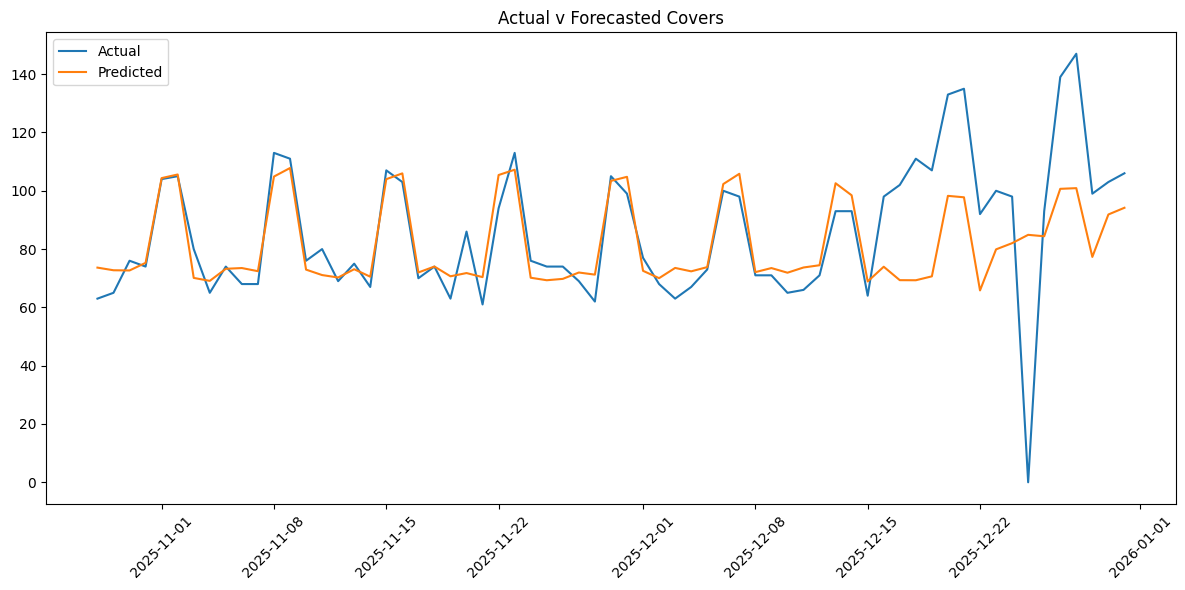

In [61]:
# --- Forecast v Actual Visualization ---

plt.figure(figsize=(12,6))

plt.plot(test['date'], y_test, label="Actual")
plt.plot(test['date'], rf_preds, label="Predicted")

plt.legend()
plt.title("Actual v Forecasted Covers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

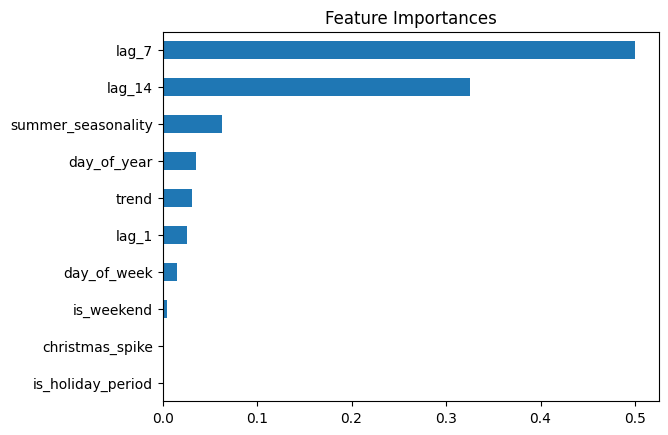

In [62]:
# --- Feature Importance ---

importances = pd.Series(rf_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importances')
plt.show()

In [ ]:
# --- Model Refinement: Remove lag_1 based on low importance ---

refined_features = [f for f in features if f != 'lag_1']

# Train refined model
rf_refined = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)
rf_refined.fit(train[refined_features], train['covers'])

refined_preds = rf_refined.predict(test[refined_features])

# Evaluate metrics
refined_mae = mean_absolute_error(test['covers'], refined_preds)
refined_rmse = np.sqrt(mean_squared_error(test['covers'], refined_preds))
refined_r2 = r2_score(test['covers'], refined_preds)
refined_residual_std = np.std(test['covers'] - refined_preds)

# Comparison with original model
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2", "Residual Std"],
    "Initial Model (with lag_1)": [
        initial_mae,
        initial_rmse,
        initial_r2,
        initial_residual_std
    ],
    "Refined Model (without lag_1)": [
        refined_mae,
        refined_rmse,
        refined_r2,
        refined_residual_std
    ]
})
comparison

# Save model comparison metrics summary
comparison.to_csv("outputs/tables/model_metric_summary.csv")

,Metric,Initial Model (with lag_1),Refined Model (without lag_1)
0,MAE,11.318677,11.204985
1,RMSE,18.408384,18.076135
2,R2,0.378962,0.401177
3,Residual Std,18.022672,17.667315


From the evaulation comparison, removing lag_1 improved the model slightly and reduced the compexity of the model. Lag_1 may have been introducing some short term noise rather than providing a clear and useful signal.

The resulting action here is that the full model training will be done without the lag_1 feature.

In [64]:
# --- Baseline Models ---

# Simple naive using lag_1
baseline_preds_l1 = test['lag_1']
baseline_mae_l1 = mean_absolute_error(y_test, baseline_preds_l1)

# Seasonal naive using lag_7
baseline_preds_l7 = test['lag_7']
baseline_mae_l7 = mean_absolute_error(y_test, baseline_preds_l7)


print("Baseline MAE (Lag-1):", round(baseline_mae_l1, 2))
print("Baseline MAE (Lag-7):", round(baseline_mae_l7, 2))


Baseline MAE (Lag-1): 17.12
Baseline MAE (Lag-7): 11.48


In [65]:
# --- Linear Regression model  ---

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_preds = lin_model.predict(X_test)
lin_mae = mean_absolute_error(y_test, lin_preds)

print("Linear Regression MAE:", round(lin_mae, 2))


Linear Regression MAE: 12.4


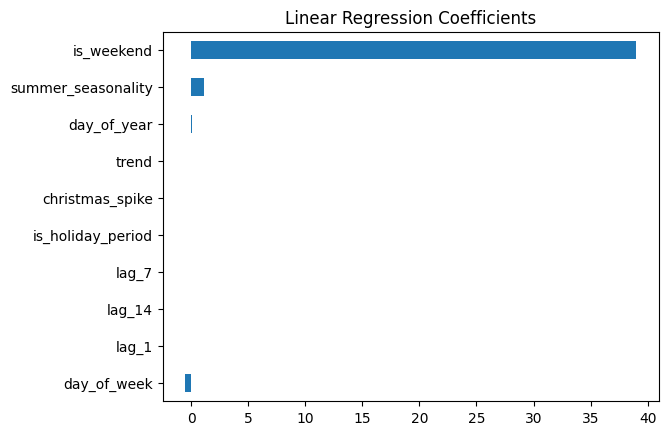

In [66]:
# --- Linear Regession Coefficients ---

coef_df = pd.Series(lin_model.coef_, index=features)
coef_df.sort_values().plot(kind='barh')
plt.title("Linear Regression Coefficients")
plt.show()


In [ ]:
# --- Model Comparison (MAE) ---

print("\nModel Comparison:")
print("-------------------")

print("Simple Naive MAE - lag_1:", round(baseline_mae_l1, 2))
print("Weekly Naive MAE - lag_7:", round(baseline_mae_l7, 2))
print("Linear Regression MAE:", round(lin_mae, 2))
print("Random Forest MAE:", round(initial_mae, 2))


Model Comparison:
-------------------
Simple Naive MAE - lag_1: 17.12
Weekly Naive MAE - lag_7: 11.48
Linear Regression MAE: 12.4
Random Forest MAE: 11.32


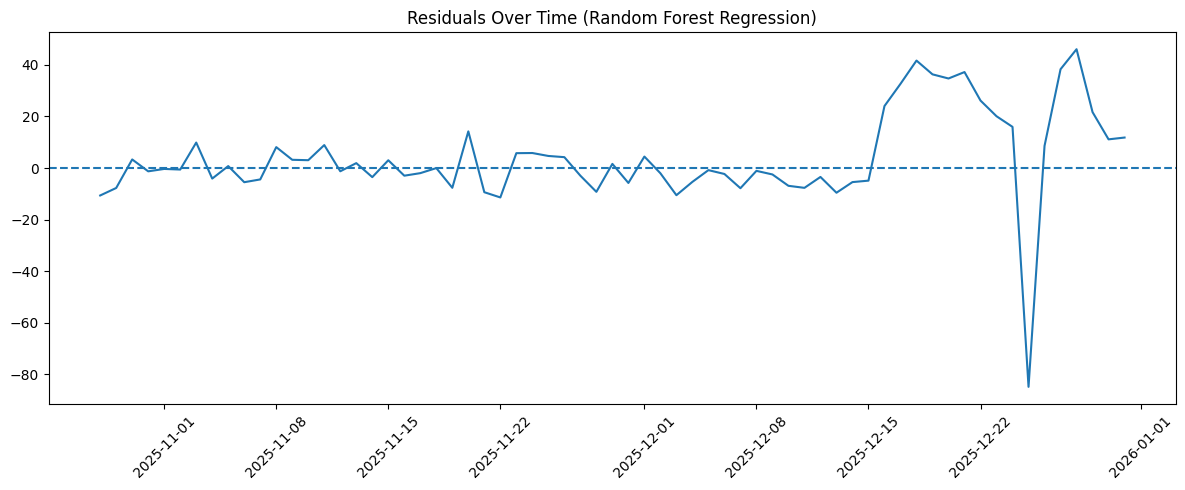

In [68]:
# --- Residual Analysis (Random Forest Regressor) ---

rf_residuals = y_test - rf_preds

plt.figure(figsize=(12,5))
plt.plot(test['date'], rf_residuals)
plt.axhline(0, linestyle='--')
plt.title("Residuals Over Time (Random Forest Regression)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

I've evaluated different forecasting approaches here:
    - Naive basline (lag-1 & lag-7) 
    - Random Forest Regressor
    - Linear Regression

I compared MAE's of each and given the available information
and nature of the problem it makes sense to continue with
the Random Forest Regressor for the purposes of this
project.

From a business point of view, the model provides
stable and interpretable forecasts that are suitable
for short-term operational planning. This model also 
handles the non-linear seasonality aspect.

In [69]:
# --- Retrain Model Using Full Dataset ---

rf_full_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42
)

X_full = covers[refined_features]
y_full = covers['covers']

rf_full_model.fit(X_full, y_full)

print("Random Forest model trained on full 2025 data.")

Random Forest model trained on full 2025 data.


In [74]:
# --- Forecast Covers for 2026 (Random Forest) ---

forecast_df = covers.copy()


# Generate future dates (2026)
future_dates = pd.date_range(start=forecast_df['date'].max() + pd.Timedelta(days=1), periods=365)
future = pd.DataFrame({'date': future_dates})
forecast_df = pd.concat([forecast_df, future], ignore_index=True)


# Recreate all non-lag features
forecast_df['day_of_week'] = forecast_df['date'].dt.dayofweek
forecast_df['is_weekend'] = forecast_df['day_of_week'].isin([5, 6]).astype(int)
forecast_df['day_of_year'] = forecast_df['date'].dt.dayofyear


# Xmas spike
forecast_df['christmas_spike'] = 0

forecast_df.loc[
    (forecast_df['date'].dt.month == 12) &
    (forecast_df['date'].dt.day >= 20),
    'christmas_spike'
] = 60


# Extend trend forward smoothly
daily_increment = 10 / 365
forecast_df['trend'] = np.arange(len(forecast_df)) * daily_increment


# Summer seasonality (same formula as simulation)
forecast_df['summer_seasonality'] = 35 * np.exp(
    -((forecast_df['day_of_year'] - 200) ** 2) /
    (2 * 40 ** 2))


# Holiday period flag (2026)
holiday_dates_2026 = pd.to_datetime([
    "2026-01-01", "2026-01-06", "2026-12-20", "2026-12-21",
    "2026-12-22", "2026-12-23", "2026-12-24", "2026-12-25",
    "2026-12-26", "2026-12-27", "2026-12-28", "2026-12-29",
    "2026-12-30", "2026-12-31"
])
forecast_df['is_holiday_period'] = forecast_df['date'].isin(holiday_dates_2026).astype(int)


# Prepare covers column for recursion
forecast_df.loc[len(covers):, 'covers'] = np.nan
historical_mean = covers['covers'].mean()


# Recursive forecast loop
for i in range(len(covers), len(forecast_df)):

    #forecast_df.loc[i, 'lag_1']  = forecast_df.loc[i-1, 'covers']
    forecast_df.loc[i, 'lag_7']  = forecast_df.loc[i-7, 'covers']  if i-7 >= 0 else historical_mean
    forecast_df.loc[i, 'lag_14'] = forecast_df.loc[i-14, 'covers'] if i-14 >= 0 else historical_mean

    row = forecast_df.loc[i, refined_features].to_frame().T
    forecast_df.loc[i, 'covers'] = rf_full_model.predict(row)[0]


# Extract 2026 forecast
forecast_2026 = forecast_df[forecast_df['date'].dt.year == 2026]

print(forecast_2026['covers'].describe())

print("Actual Covers 2025:", round(covers['covers'].sum()))
print("Forecasted Total Covers 2026:", round(forecast_2026['covers'].sum(), 2))
print("Forecasted Average Covers 2026:", round(forecast_2026['covers'].mean(), 2))

count    365.000000
mean     100.625364
std        9.302261
min       70.480000
25%       97.284000
50%       99.014000
75%      106.200000
max      123.894000
Name: covers, dtype: float64
Actual Covers 2025: 30283
Forecasted Total Covers 2026: 36728.26
Forecasted Average Covers 2026: 100.63


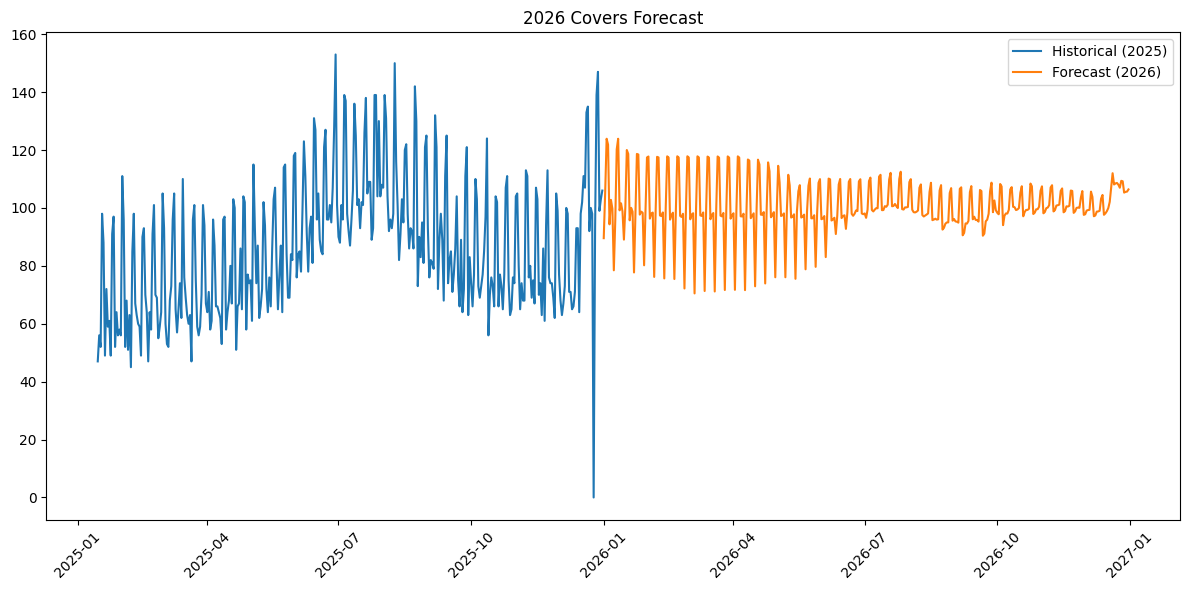

In [75]:
# --- Plot 2025 v 2026 ---

plt.figure(figsize=(12,6))

# Plot last years actuals
plt.plot(covers['date'], covers['covers'], label="Historical (2025)")

# Plot forecast 
plt.plot(forecast_2026['date'], forecast_2026['covers'], label="Forecast (2026)")

plt.legend()
plt.title("2026 Covers Forecast")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

              feature  importance
0               lag_7    0.392484
1              lag_14    0.391843
6  summer_seasonality    0.066739
8               trend    0.053897
4         day_of_year    0.052304
2         day_of_week    0.020877
7     christmas_spike    0.010844
3          is_weekend    0.007750
5   is_holiday_period    0.003263


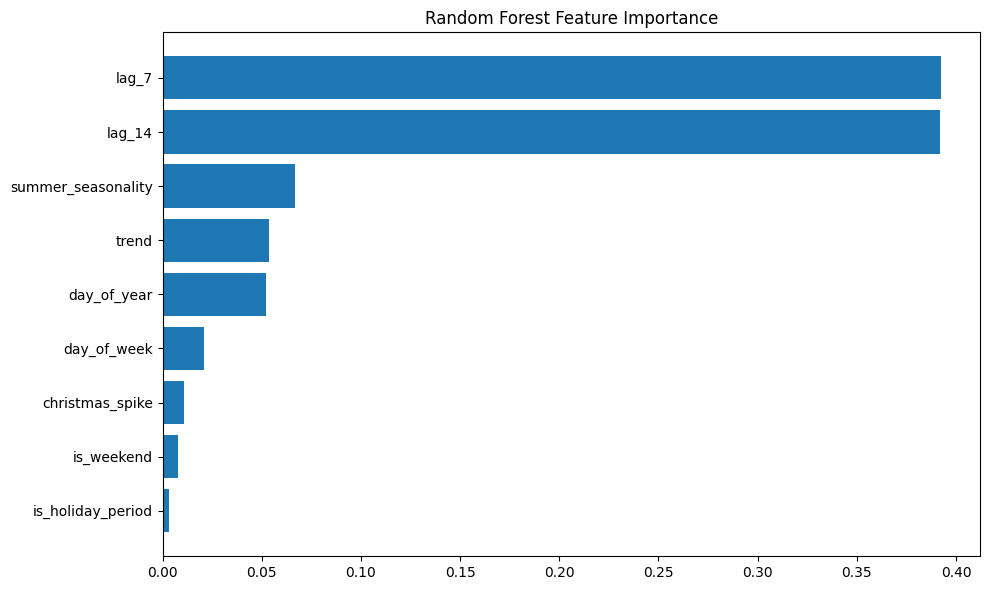

In [76]:
# --- Fully trained model feature importance ---

importances = rf_full_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': refined_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(importance_df)

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()